Name: Manahil Fatima

Class: BS-CS5

Section: H

CMS: 023-24-0249

Github link: https://github.com/ManahilFatima16/ml-lab4-machine-learning-models

Dataset: Telco churn Dataset from kaggle 

Kaggle Profile: https://www.kaggle.com/manahilmemon12

In [2]:
#Part 1
#Task 1
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
#Step 1 in this first we load the cleaned dataset 
df = pd.read_csv('clean_churn.csv')
print(df.shape)
df.info()
#Step 2 in this we have to define target and features 
y = df["Churn"].map({"Yes": 1,"No":0})
X = df.drop(columns=["Churn"])
#step 3 in this we have to make categorical columns into numericals 
X = pd.get_dummies(X,columns=[
    "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod"
],drop_first=True)
#Step 4 in this we train/test split 
X_train,X_test,y_train,y_test = train_test_split(
X,y, test_size=0.2, random_state=42,stratify=y
)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(7043, 20)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   str    
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    


In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
#choose best_depth which we choosen in lab 3
best_depth = 5
#in this step how can we make model and train 
final_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
final_model.fit(X_train,y_train)
#prediction on test set 
final_pred = final_model.predict(X_test)
#Now we have to calculate the metrics 
final_acc = accuracy_score(y_test,final_pred)
final_prec = precision_score(y_test,final_pred)
final_rec = recall_score(y_test,final_pred)
final_f1 = f1_score(y_test,final_pred)
#print this calculations metrics 
print("Decision Tree BaseLine")
print(pd.DataFrame({
    'Metrics' : ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [final_acc, final_prec, final_rec, final_f1]
}))

Decision Tree BaseLine
     Metrics     Score
0   Accuracy  0.794180
1  Precision  0.631250
2     Recall  0.540107
3   F1-Score  0.582133


In [5]:
#Part 2 - Task 3 
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators= 200, random_state=42)
rf_model.fit(X_train,y_train)
rf_pred = rf_model.predict(X_test)
print("Random Forest Trained SuccessFully!")
print("Prediction shape: ", rf_pred.shape)
      

Random Forest Trained SuccessFully!
Prediction shape:  (1409,)


In [6]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
rf_acc = accuracy_score(y_test,rf_pred)
rf_prec = precision_score(y_test,rf_pred)
rf_rec = recall_score(y_test,rf_pred)
rf_f1 = f1_score(y_test,rf_pred)
print("Random Forest Results ")
print(pd.DataFrame({
    'Metrics': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [rf_acc, rf_prec, rf_rec, rf_f1]
}))

Random Forest Results 
     Metrics     Score
0   Accuracy  0.794890
1  Precision  0.643098
2     Recall  0.510695
3   F1-Score  0.569300


In [7]:
import pandas as pd
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Decision Tree (Part 1)': [final_acc, final_prec, final_rec, final_f1],
    'Random Forest (Part 2)': [rf_acc, rf_prec, rf_rec, rf_f1]
})

print(comparison_df)

      Metric  Decision Tree (Part 1)  Random Forest (Part 2)
0   Accuracy                0.794180                0.794890
1  Precision                0.631250                0.643098
2     Recall                0.540107                0.510695
3   F1-score                0.582133                0.569300


Task 4 

An individual unrestricted tree can memorize the training data too much and become overfitted, whereas a Random Forest trains many trees on different random samples and averages their predictions. This helps reduce the effect of individual trees’ overfitting, allowing the model to generalize more reliably to new data.

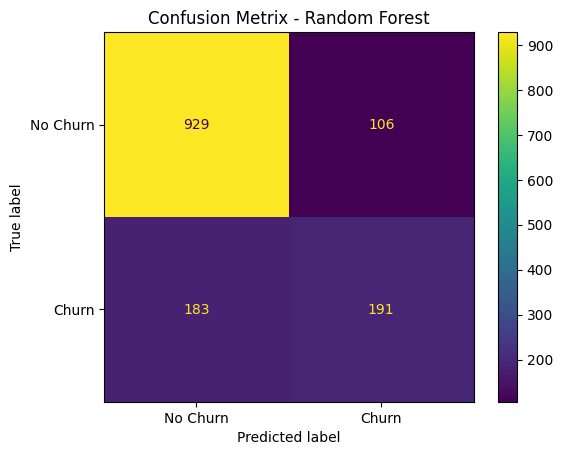

In [9]:
#Part 3 - Task 5 
#We already calculate metrics of random forest in the previous tasks just no we have to plot the confusion matrix 
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_rf = confusion_matrix(y_test,rf_pred)
ConfusionMatrixDisplay(cm_rf, display_labels= ['No Churn','Churn']).plot()
plt.title('Confusion Metrix - Random Forest')
plt.show()


In [10]:
#Part 3 - Task 6
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Decision Tree (Part 1)': [final_acc, final_prec, final_rec, final_f1],
    'Random Forest (Part 2)': [rf_acc, rf_prec, rf_rec, rf_f1]
})
print(comparison_df)

      Metric  Decision Tree (Part 1)  Random Forest (Part 2)
0   Accuracy                0.794180                0.794890
1  Precision                0.631250                0.643098
2     Recall                0.540107                0.510695
3   F1-score                0.582133                0.569300


Task 7

Random Forest was slightly better in Accuracy and Precision, but Decision Tree performed better in Recall (~3%) and F1-score (~1.3%). Since our dataset is imbalanced (73% No Churn, 27% Churn), Recall and F1-score are more important for detecting churners. Therefore, in this case, the Decision Tree generalized better, showing that an ensemble model is not always the best choice.


In [15]:
#Part 4 - Task 8
from sklearn.model_selection import cross_val_score 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import numpy as np
#CV for decision Tree
dt_model_cv = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_cv_scores = cross_val_score(dt_model_cv, X,y,cv=5, scoring='f1')
print("Decision Tree CV F1 scores (perfold):",dt_cv_scores)
print("Decision Tree Mean F1:", dt_cv_scores.mean())
print("Decision Tree Std F1:", dt_cv_scores.std())
print()
#cv for Random Forest
rf_model_cv = RandomForestClassifier(n_estimators = 200, random_state= 42)
rf_cv_scores = cross_val_score(rf_model_cv, X, y, cv=5, scoring='f1') 
print("Random Forest Tree CV F1 scores (perfold):",rf_cv_scores)
print("Random Forest Tree Mean F1:", rf_cv_scores.mean())
print("Random Forest Tree Std F1:", rf_cv_scores.std())


Decision Tree CV F1 scores (perfold): [0.56842105 0.4770017  0.47947455 0.52072968 0.53666147]
Decision Tree Mean F1: 0.516457691203321
Decision Tree Std F1: 0.03478839232815095

Random Forest Tree CV F1 scores (perfold): [0.55130168 0.55235205 0.5280236  0.58346334 0.5753012 ]
Random Forest Tree Mean F1: 0.5580883750528448
Random Forest Tree Std F1: 0.019611352120678136


##Task 9 

The cross-validation results change our view from the single train/test split. In Part 3, the Decision Tree had a slightly higher F1-score (0.582 vs. 0.569), but 5-fold cross-validation shows that Random Forest has a higher average F1-score (0.558 vs. 0.516). Therefore, Random Forest appears to generalize better across different data splits, and we are more confident in choosing Random Forest based on the cross-validated results.

In [17]:
#Part 5 - Task 10
#Hyperparameter tuning for Random Forest using GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
#first we have to define a small grid 
param_grid = {
    'n_estimators': [100,200,300],
    'max_depth': [5,10,None],
    'min_samples_split': [2,5,10]
}
#Base Model
rf_base = RandomForestClassifier(random_state=42)
#GridSearchCV setup
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1'
)
grid_search.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >

In [18]:
#Part 5 - Task 11
#Report Best hyperparameters and cv score 
print("Best Hyperparameters: ", grid_search.best_params_)
print("Best CV F1-score: ", grid_search.best_score_)

best_rf_model = grid_search.best_estimator_

Best Hyperparameters:  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1-score:  0.5708325877335344


In [19]:
#Part 5 - Task 12 
# Evaluate tuned model on held-out test set
from sklearn.metrics import accuracy_score,precision_score, recall_score,f1_score
tuned_pred = best_rf_model.predict(X_test)

tuned_acc = accuracy_score(y_test,tuned_pred)
tuned_prec = precision_score(y_test,tuned_pred)
tuned_rec = recall_score(y_test,tuned_pred)
tuned_f1 = f1_score(y_test,tuned_pred)

print("=======Tuned Random Forest Results(Test Set)=======")
print(pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Score': [tuned_acc, tuned_prec, tuned_rec, tuned_f1]
}))

=======Tuned Random Forest Results(Test Set)=======
      Metric     Score
0   Accuracy  0.804826
1  Precision  0.662295
2     Recall  0.540107
3   F1-score  0.594993


In [20]:
#Part 6 - Task 13
#Final Comparison And Feature Importance 
final_comparison_df = pd.DataFrame({
   'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Decision Tree': [final_acc, final_prec, final_rec, final_f1],
    'Random Forest (default)': [rf_acc, rf_prec, rf_rec, rf_f1],
    'Random Forest (tuned)': [tuned_acc, tuned_prec, tuned_rec, tuned_f1] 
})
print(final_comparison_df)

      Metric  Decision Tree  Random Forest (default)  Random Forest (tuned)
0   Accuracy       0.794180                 0.794890               0.804826
1  Precision       0.631250                 0.643098               0.662295
2     Recall       0.540107                 0.510695               0.540107
3   F1-score       0.582133                 0.569300               0.594993


#Task 14

I chose the Tuned Random Forest as my final model because it achieved the highest F1-score (0.595) and the highest accuracy (0.805). It also achieved the same Recall (0.540) as the Decision Tree while having better Precision. Therefore, the Tuned Random Forest provides the best overall performance for our imbalanced churn dataset.


tenure                            0.191132
TotalCharges                      0.157462
MonthlyCharges                    0.120849
InternetService_Fiber optic       0.064952
PaymentMethod_Electronic check    0.060395
Contract_Two year                 0.057835
Contract_One year                 0.036472
OnlineSecurity_Yes                0.031953
TechSupport_Yes                   0.026817
PaperlessBilling_Yes              0.022845
dtype: float64


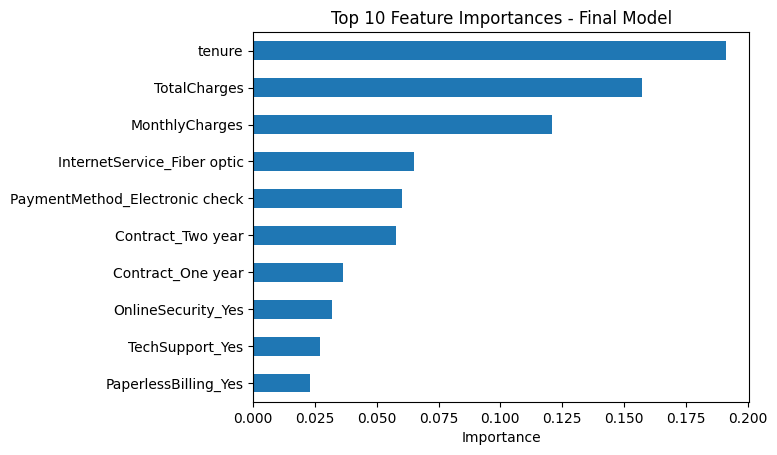

In [21]:
# Part 6 — Task 15
# Extract and visualize feature importances of final model
import matplotlib.pyplot as plt
importances = pd.Series(
    best_rf_model.feature_importances_,   # apne chosen final model se replace karein
    index=X.columns
).sort_values(ascending=False)
print(importances.head(10))

importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances - Final Model')
plt.show()


In [23]:
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [24]:
# Task 16

submission_predictions = best_rf_model.predict(X_test)

submission_df = pd.DataFrame({
    'customerID': X_test.index,
    'Churn': submission_predictions
})

submission_df.to_csv('submission.csv', index=False)

print(submission_df.head())

   customerID  Churn
0         437      0
1        2280      1
2        2235      0
3        4460      0
4        3761      0


In [25]:
import os
print(os.path.exists('submission.csv'))

True


Task 17 — Conclusion

In this lab, I compared the Decision Tree with Random Forest and performed hyperparameter tuning. I selected the Tuned Random Forest as my final model because it achieved the highest F1-score of 0.595, compared with 0.582 for the Lab 3 Decision Tree. It also achieved a Recall of 0.540, which is important for detecting churners in our imbalanced dataset. However, the model still misses some actual churners, and class imbalance was not directly handled.

Task 18 — Future Improvements

If I had more time, I would address the class imbalance using class_weight='balanced' or SMOTE to improve churn detection. I would also try other algorithms such as Logistic Regression, Gradient Boosting, and XGBoost. In addition, I would perform deeper hyperparameter tuning and feature engineering to create more useful predictors. These approaches could potentially improve the model's ability to identify customers who are likely to churn.